In [33]:
#파이썬의 행렬과 관련된 수학식을 사용할 수 있는 라이브러리
import numpy as np

#데이터분석용 pandas 사용을 위한 라이브러리
import pandas as pd

#그래프 시각화를 위한 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm  #시각화 폰트

#문자데이터를 숫자로 인코딩 하기 위한 라이브러리
from sklearn.preprocessing import LabelEncoder

#전체 데이터를 학습용 데이터와 검증용 데이터로 나누기 위한 라이브러리
from sklearn.model_selection import train_test_split

#회귀 분석 평가 지표 사용을 위한 라이브러리
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
#폰트 확인

for f in fm.fontManager.ttflist:
  name = f.name
  if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Apple', 'Batang', 'Gulim']):
      print(name)

#나눔고딕 폰트로 그래프 폰트 변경(한글 깨짐 방지)
fm._load_fontmanager(try_read_cache=False)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

HCR Batang Ext
Copperplate Gothic Bold
MJemokBatang
NanumGothic
HCR Batang ExtB
Batang
BatangChe
MJemokGothic
Franklin Gothic Demi Cond
NanumGothic
Yu Gothic
Yu Gothic UI
Yu Gothic UI
Yu Gothic UI Semibold
HCR Batang ExtB
HYGothic-Medium
Century Gothic
Franklin Gothic Medium
MS Gothic
MS UI Gothic
MS PGothic
Century Gothic
Century Gothic
Franklin Gothic Heavy
Gulim
GulimChe
Franklin Gothic Book
HCR Batang
Franklin Gothic Demi
NanumGothic
NanumGothicExtraBold
Franklin Gothic Medium Cond
Franklin Gothic Book
Franklin Gothic Demi
Malgun Gothic
HCR Batang
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
New Gulim
Century Gothic
Copperplate Gothic Light
HYGothic-Extra
Franklin Gothic Medium
Malgun Gothic
Showcard Gothic
Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
MBatang
Yu Gothic
Yu Gothic Light
Yu Gothic UI
Yu Gothic UI Light
Malgun Gothic
Malgun Gothic Semilight
Franklin Gothic Heavy


In [6]:
df = pd.read_csv('가스_인구_기온_통합.csv',encoding='cp949')
df

,연월,시도,월평균기온,월평균최고기온,월평균최저기온,가구수(개),공급량(㎥),총인구수
0,2021-01,강원,-4.2,1.5,-9.7,386599,51918.194190,1541696
1,2021-02,강원,1.3,7.3,-4.6,387774,43068.962620,1540875
2,2021-03,강원,7.0,13.3,1.3,388403,32782.803000,1536399
3,2021-04,강원,11.8,17.9,5.7,390610,20762.350470,1536175
4,2021-05,강원,15.3,21.1,10.0,391098,14472.110240,1535491
...,...,...,...,...,...,...,...,...
1183,2026-02,충북,1.1,7.7,-5.0,584666,47598.860310,1596816
1184,2026-03,충북,6.8,13.6,0.5,579452,39099.270910,1597976
1185,2026-04,충북,13.5,20.6,6.4,576171,21893.604080,1599375
1186,2026-05,충북,18.6,25.5,11.8,576065,12157.524940,1600216


In [7]:
#결측치 유무 판단
df.isnull().sum()

연월         0
시도         0
월평균기온      0
월평균최고기온    0
월평균최저기온    0
가구수(개)     0
공급량(㎥)     0
총인구수       0
dtype: int64

In [8]:
#각 열에 대한 식별자를 판단
len(df) #전체 데이터의 갯수
df.nunique()   #unique 고유한 값의 갯수 파악 => 전체 데이터의 갯수와 비슷하다? = 식별자

#df.nunique() / len(df) 로 유일값 비율 계산 → 1에 가까우면 식별자.
unique_rate = df.nunique() / len(df)
print(unique_rate.sort_values(ascending=False))

총인구수       0.999158
공급량(㎥)     0.998316
가구수(개)     0.997475
월평균최저기온    0.281987
월평균최고기온    0.259259
월평균기온      0.253367
연월         0.055556
시도         0.015152
dtype: float64


In [9]:
#이상치 판단


In [34]:
#시각화(차트)를 위한 라이브러리 설치
!pip install matplotlib seaborn scipy

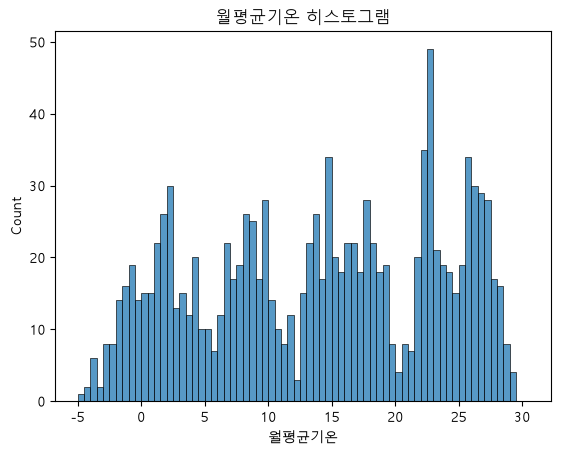

In [11]:
#히스토그램으로 가스공급량 데이터의 분포를 확인
import numpy as np
sns.histplot(df['월평균기온'], bins=np.arange(-5, 31, 0.5))
plt.title('월평균기온 히스토그램')
plt.show()

In [12]:
df['월평균기온'].max()      #29.3
df['월평균기온'].min()      #-4.8
df['월평균최고기온'].max()   #34.4
df['월평균최저기온'].min()   #-10.3

np.float64(-10.3)

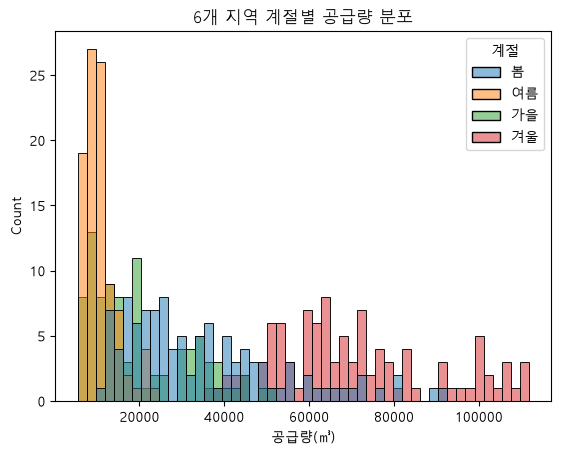

In [ ]:
#월을 계절로 매핑 함수 정의
def get_season(m) : 
  if m in [3,4,5] : return '봄'
  elif m in [6,7,8] : return '여름'
  elif m in [9,10,11] : return '가을'
  else :  return '겨울'

#지역별 데이터 정리
target = ['전북','대전','경남','경북','광주','강원']
filtered_df = df[df['시도'].isin(target)].copy()

#컬럼에서 month 추출 후 계절 이름 매핑
filtered_df['월'] = pd.to_datetime(filtered_df['연월']).dt.month
filtered_df['계절'] = filtered_df['월'].apply(get_season)

sns.histplot(
  data=filtered_df,
  x='공급량(㎥)',
  hue='계절',
  bins=50,
  hue_order=['봄', '여름', '가을', '겨울']
)

plt.title('6개 지역 계절별 공급량 분포')
plt.show()


#겨울 설정 :  12월, 1월, 2월을 겨울로 설정했지만, 22년 12월, 23년 1월, 23년 2월의 계절로 묶이지 않고 23년 1,2,12월이 겨울로 묶이게 된다 -> 그러나 겨울의 특성(특정 월이 아닌)으로 공급량을 바라본다면 월의 설정을 구분하지 않아도 괜찮다.

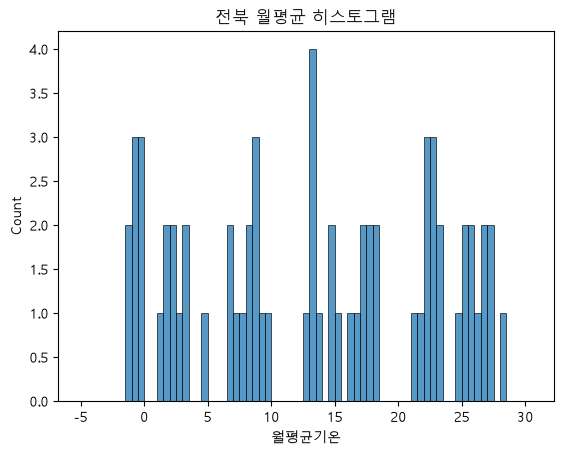

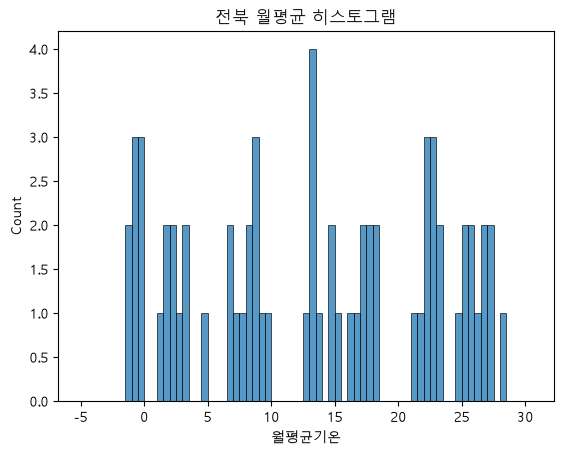

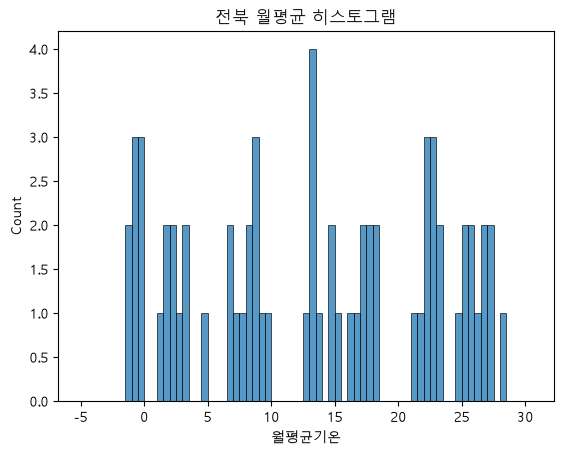

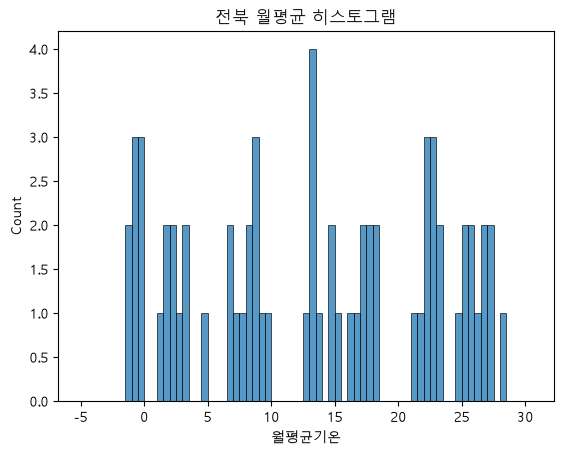

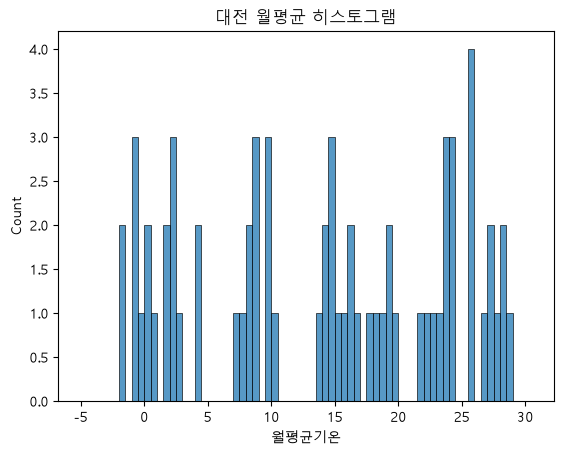

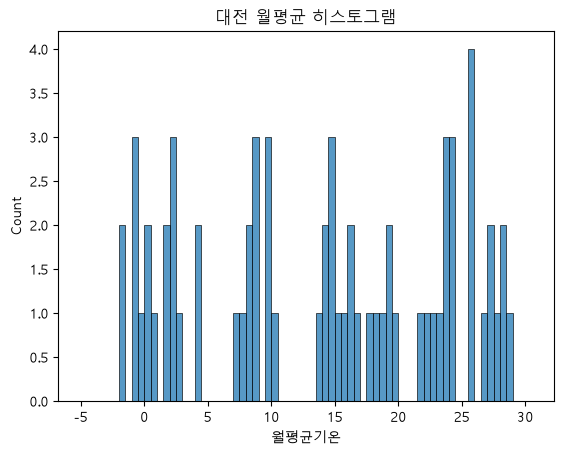

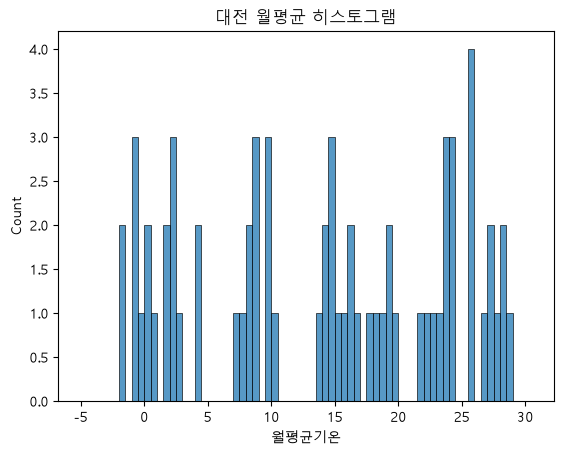

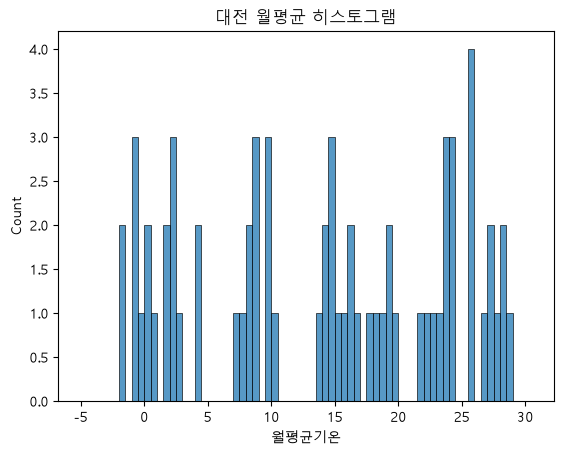

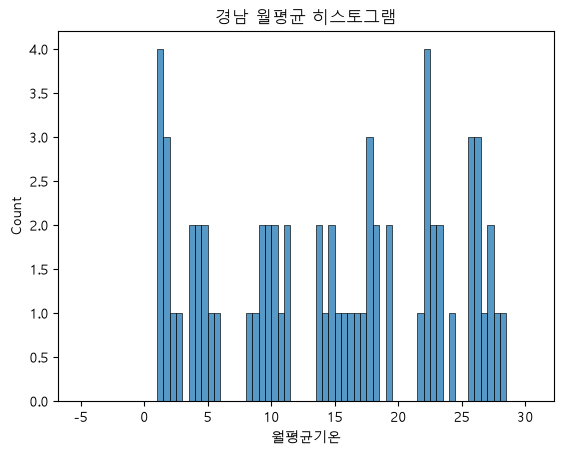

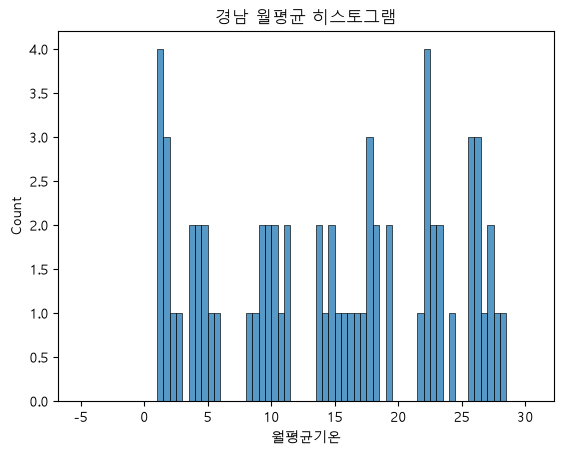

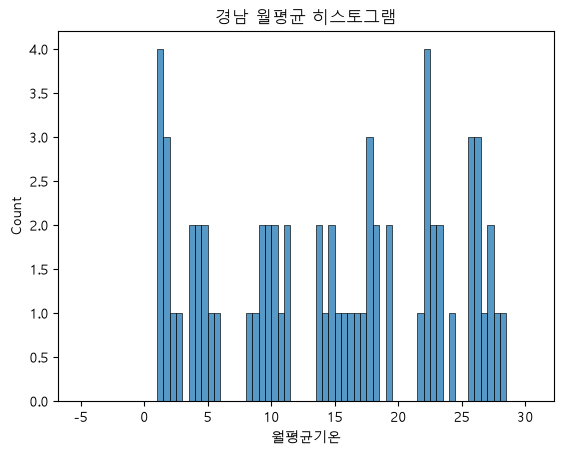

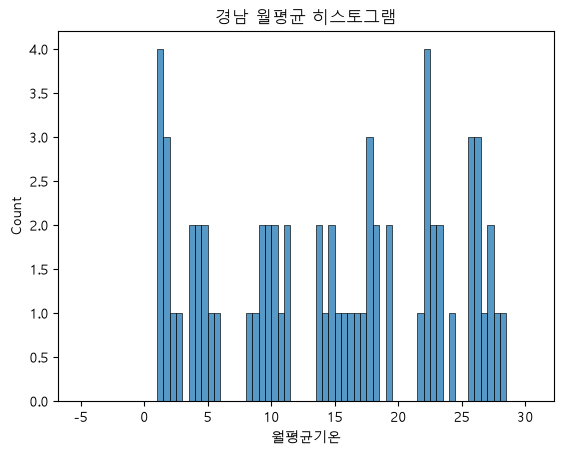

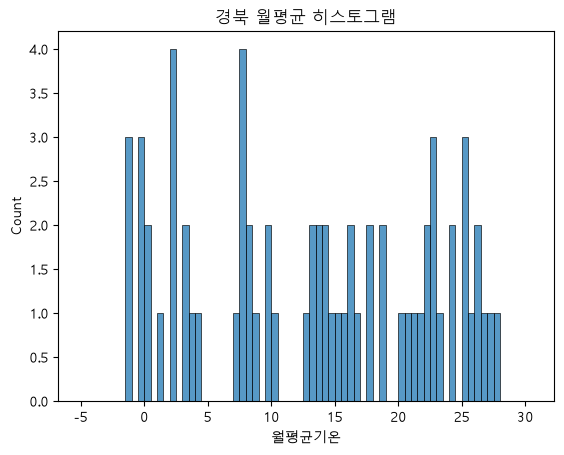

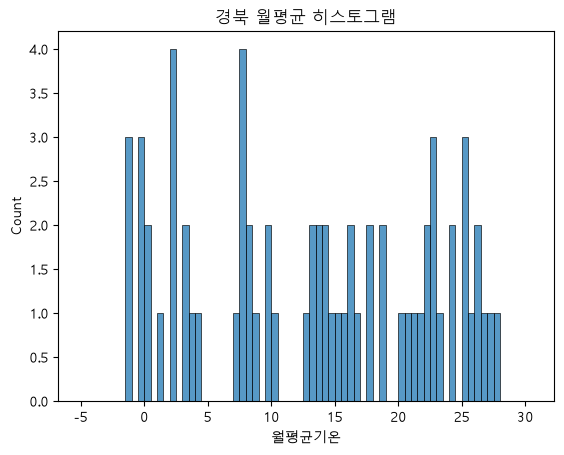

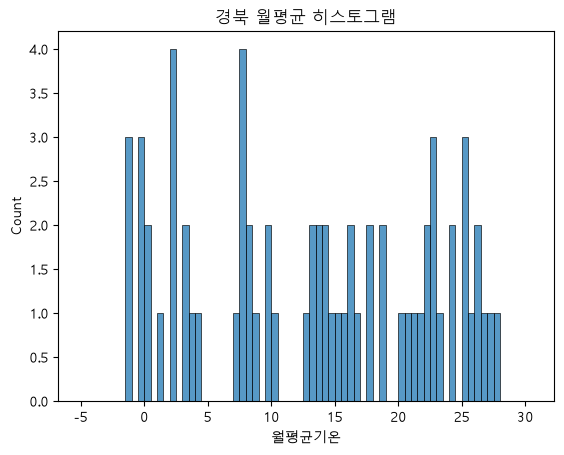

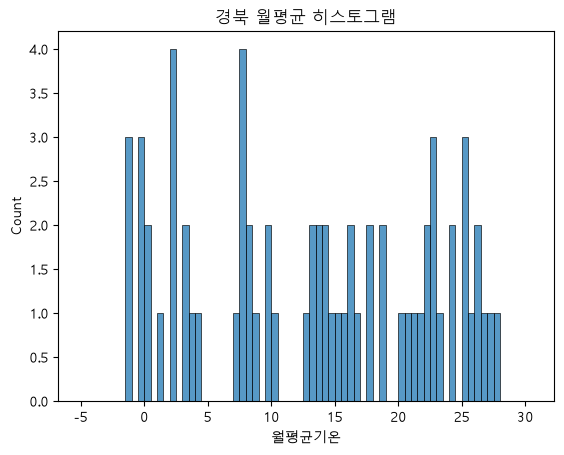

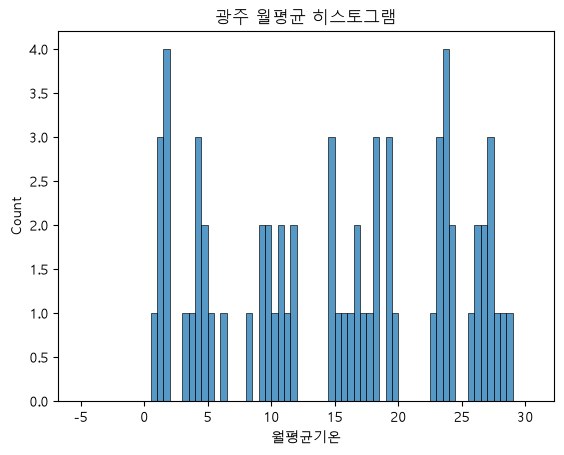

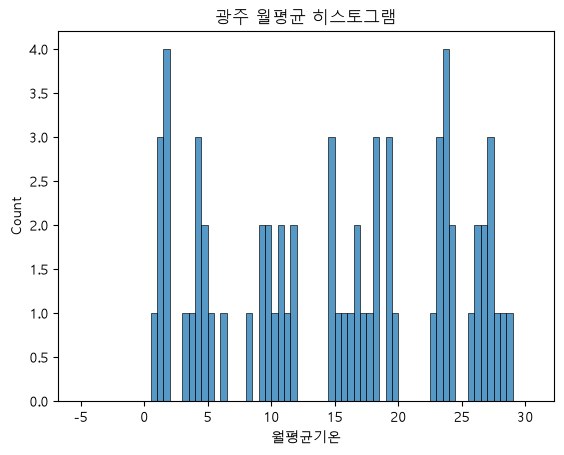

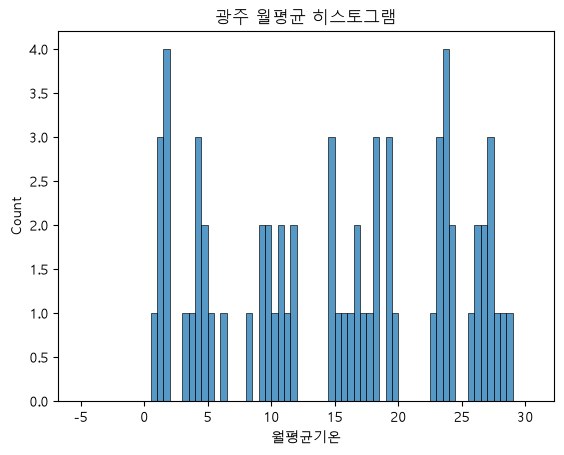

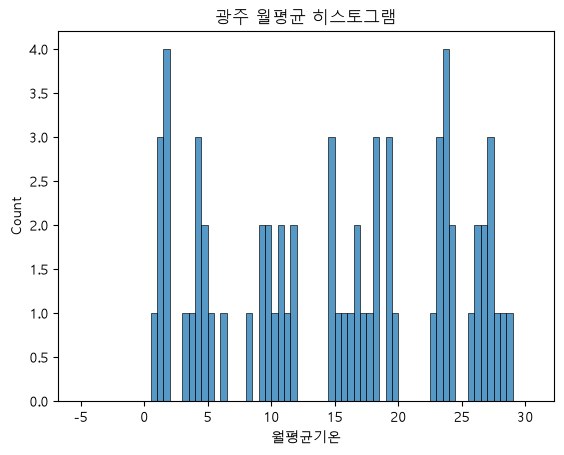

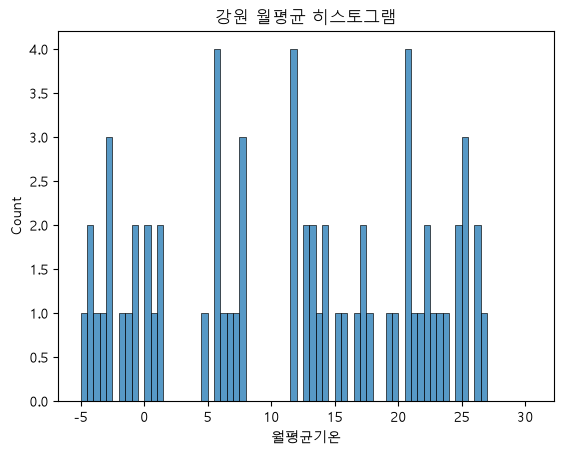

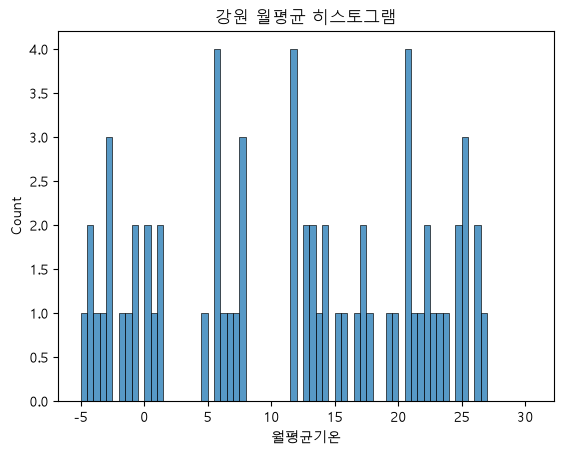

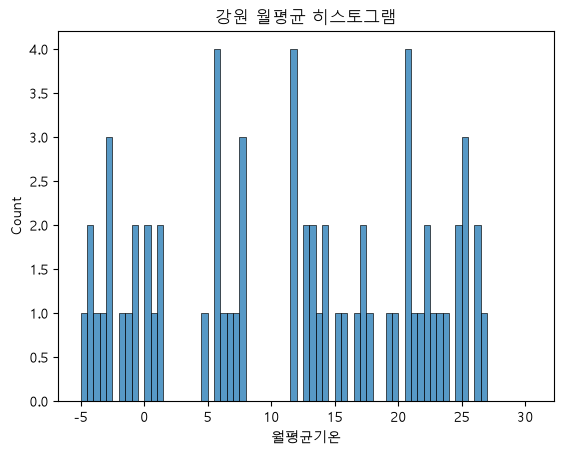

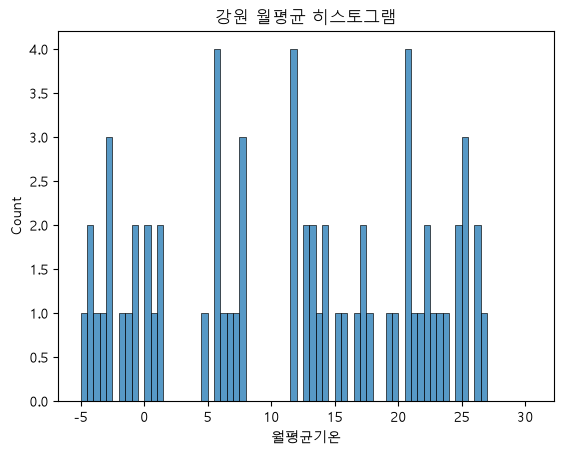

In [14]:
def get_season(m) : 
  if m in [3,4,5] : return '봄'
  elif m in [6,7,8] : return '여름'
  elif m in [9,10,11] : return '가을'
  else :  return '겨울'

target = ['전북','대전','경남','경북','광주','강원']
filtered_df = df[df['시도'].isin(target)].copy()

filtered_df['월'] = pd.to_datetime(filtered_df['연월']).dt.month
filtered_df['계절'] = filtered_df['월'].apply(get_season)

regions = ['전북','대전','경남','경북','광주','강원']
seasons = ['봄', '여름', '가을', '겨울']

for region in regions : 
  for season in seasons : 
    data = filtered_df[(filtered_df['시도'] == region)]
    sns.histplot(data['월평균기온'], bins=np.arange(-5, 31, 0.5))
    plt.title(f'{region} 월평균 히스토그램')
    plt.show()

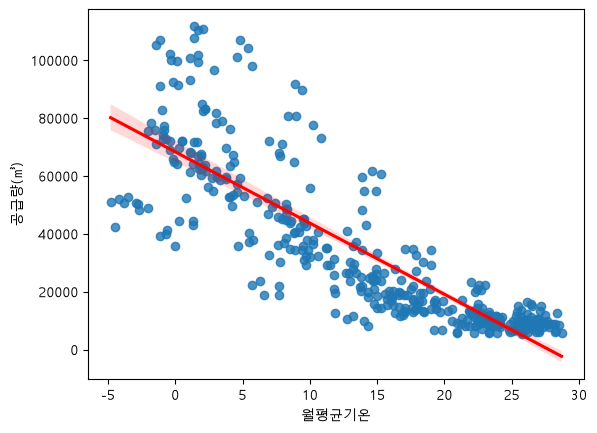

Pearson  상관계수:  -0.841,  p-value:  0.0000
Spearman  상관계수:  -0.895,  p-value:  0.0000


In [15]:
#  추세선까지  추가하면  관계  판단이  쉬움
sns.regplot(x='월평균기온',  y='공급량(㎥)',  data=filtered_df, line_kws={'color':  'red'})
plt.show()

from  scipy.stats  import  pearsonr,  spearmanr
r,  p  =  pearsonr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)'])
print(f"Pearson  상관계수:  {r:.3f},  p-value:  {p:.4f}")
r_s,  p_s  =  spearmanr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)']) 
print(f"Spearman  상관계수:  {r_s:.3f},  p-value:  {p_s:.4f}")

In [16]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

results = []
for region in regions: 
    df_region = filtered_df[filtered_df['시도'] == region]
    for season in ['봄', '여름', '가을', '겨울']: 
        season_df = df_region[df_region['계절'] == season]
        if len(season_df) > 2:
            r, p = pearsonr(season_df['월평균기온'], season_df['공급량(㎥)'])
            r_s, p_s = spearmanr(season_df['월평균기온'], season_df['공급량(㎥)'])
            results.append([region, season, round(r,3), p, round(r_s,3), p_s])

result_df = pd.DataFrame(results, columns=['지역','계절','Pearson r','Pearson p','Spearman r','Spearman p'])

# 소수점 자리수 늘려서 출력
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
print(result_df)


#강한 음 상관관계 반비례!
#pearson p 0.05 이하면 통계적으로 유의미!


    지역  계절  Pearson r  Pearson p  Spearman r  Spearman p
0   전북   봄  -0.983000   0.000000   -0.969000    0.000000
1   전북  여름  -0.847000   0.000035   -0.730000    0.001327
2   전북  가을  -0.952000   0.000000   -0.989000    0.000000
3   전북  겨울  -0.940000   0.000000   -0.945000    0.000000
4   대전   봄  -0.978000   0.000000   -0.959000    0.000000
5   대전  여름  -0.816000   0.000116   -0.777000    0.000395
6   대전  가을  -0.942000   0.000000   -0.981000    0.000000
7   대전  겨울  -0.902000   0.000001   -0.922000    0.000000
8   경남   봄  -0.966000   0.000000   -0.929000    0.000000
9   경남  여름  -0.930000   0.000000   -0.833000    0.000062
10  경남  가을  -0.931000   0.000000   -0.971000    0.000000
11  경남  겨울  -0.242000   0.348526   -0.181000    0.487379
12  경북   봄  -0.980000   0.000000   -0.961000    0.000000
13  경북  여름  -0.854000   0.000025   -0.812000    0.000134
14  경북  가을  -0.960000   0.000000   -0.963000    0.000000
15  경북  겨울  -0.917000   0.000000   -0.912000    0.000000
16  광주   봄  -0.980000   0.00000

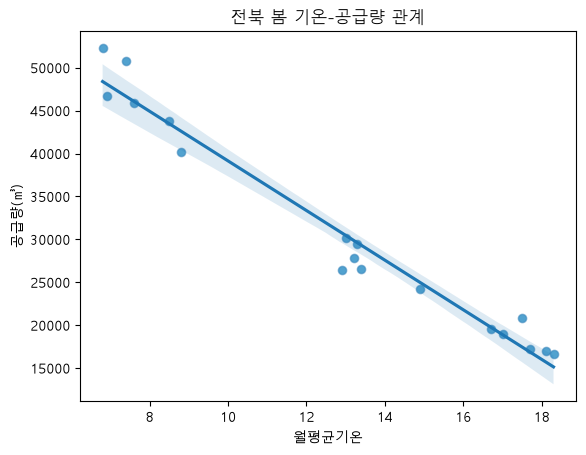

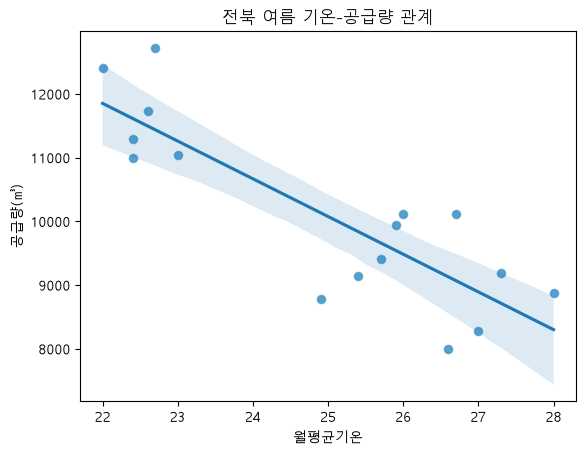

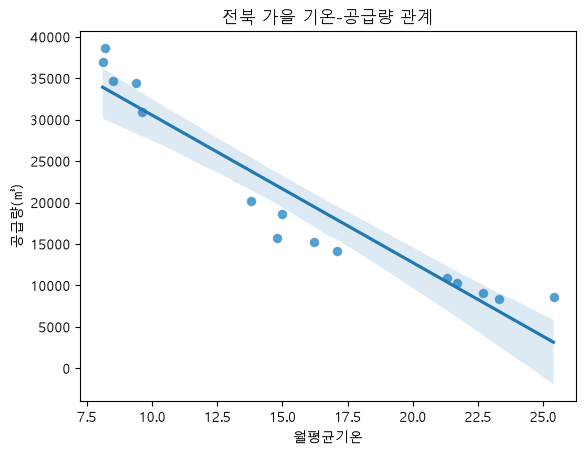

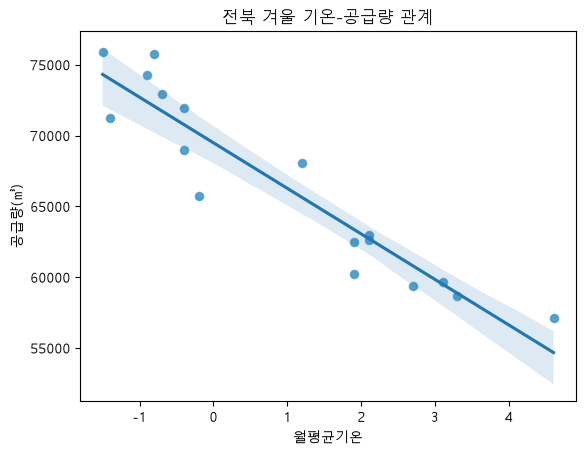

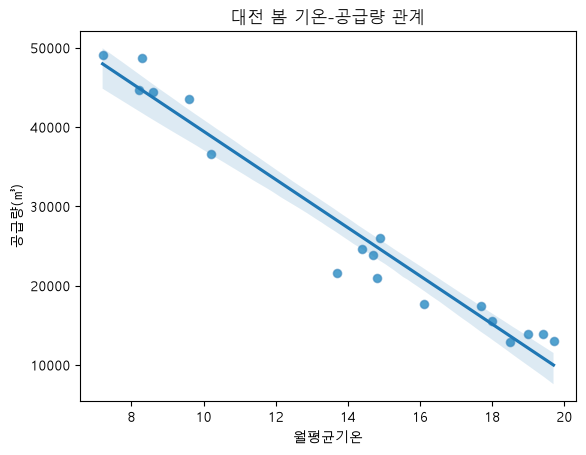

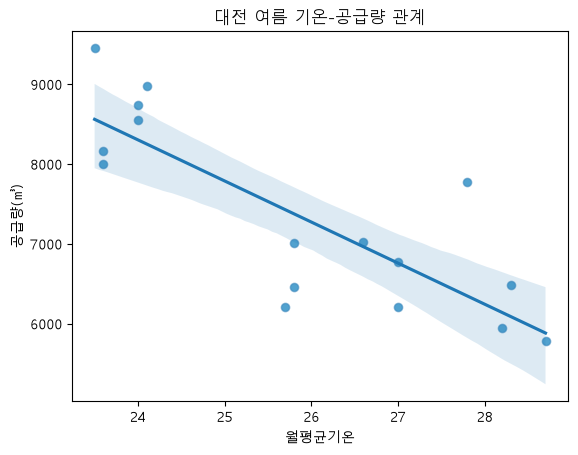

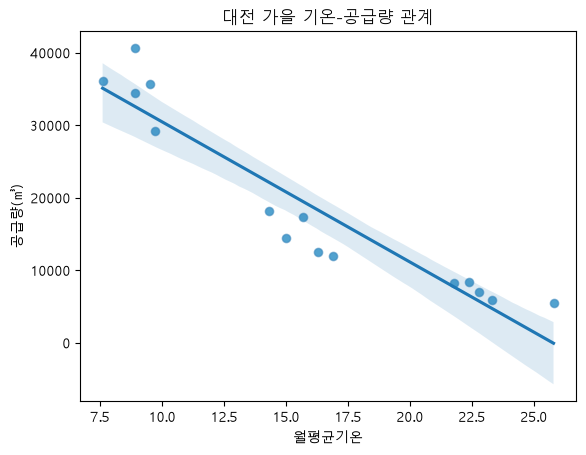

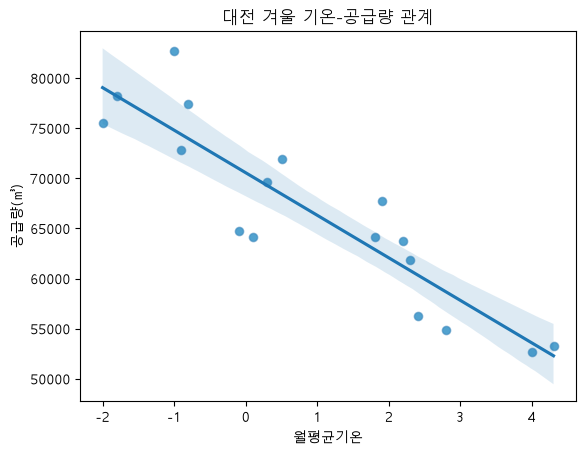

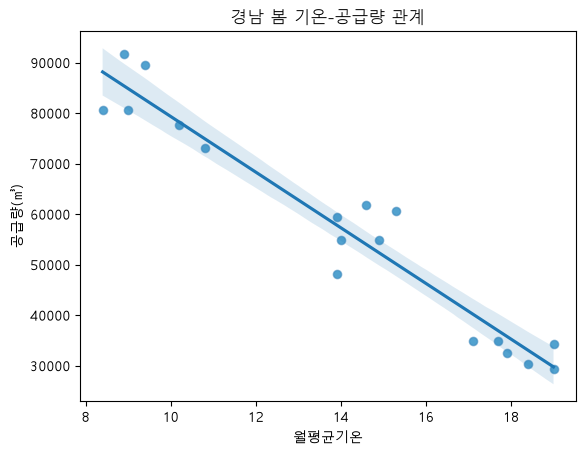

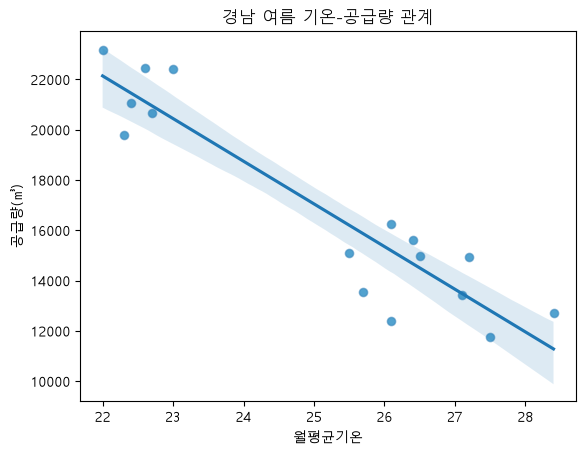

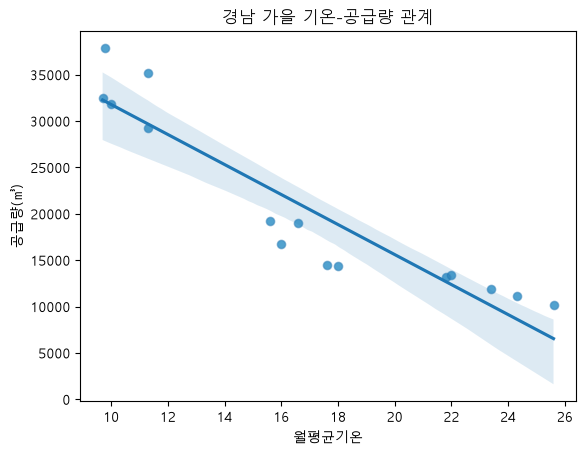

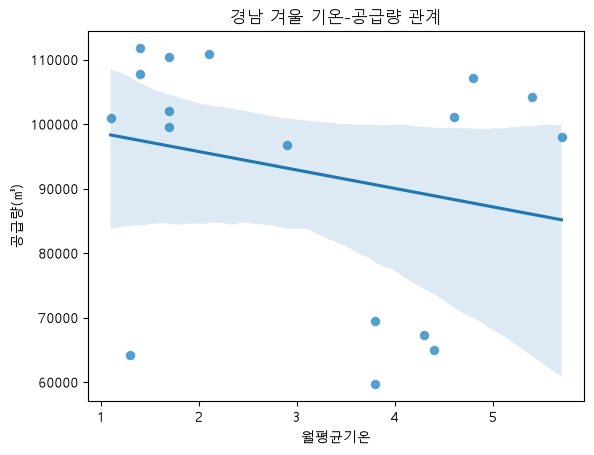

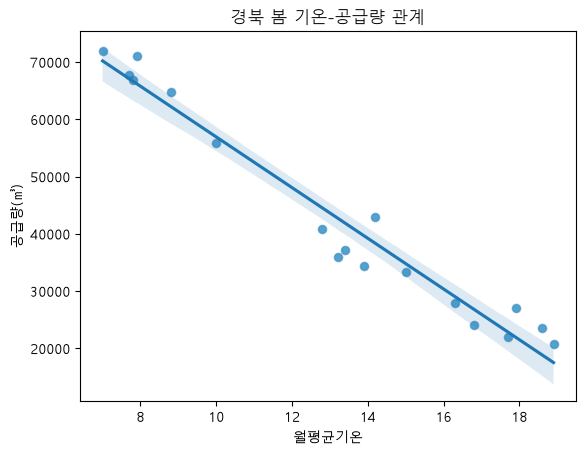

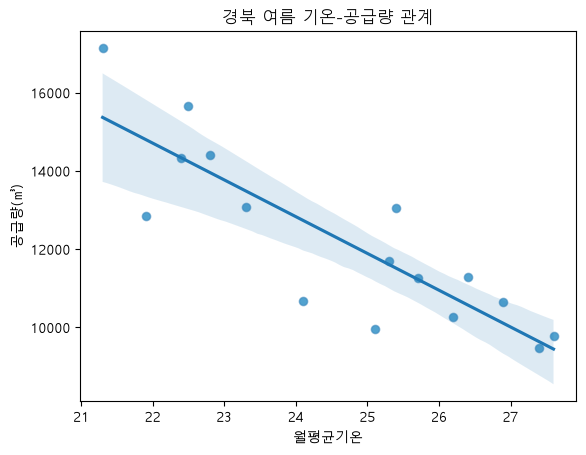

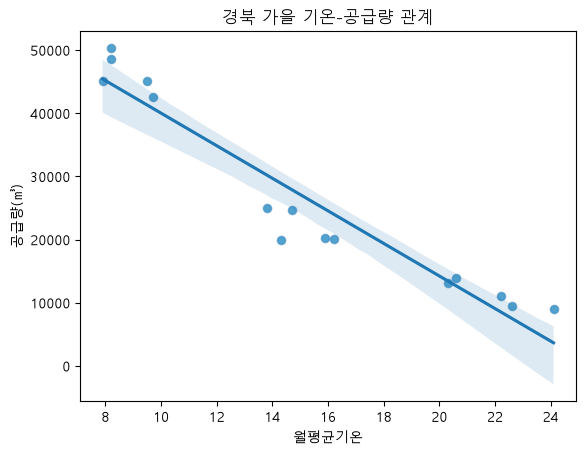

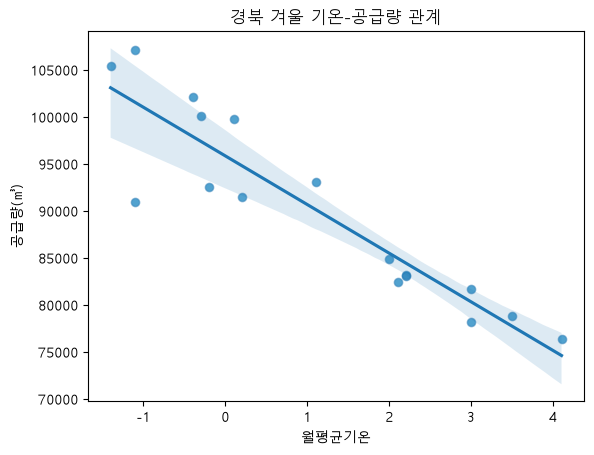

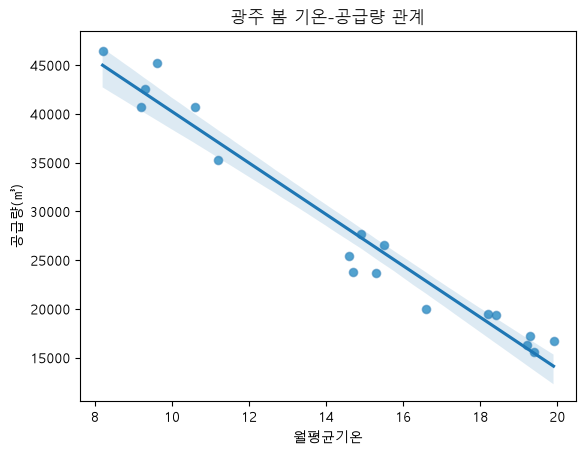

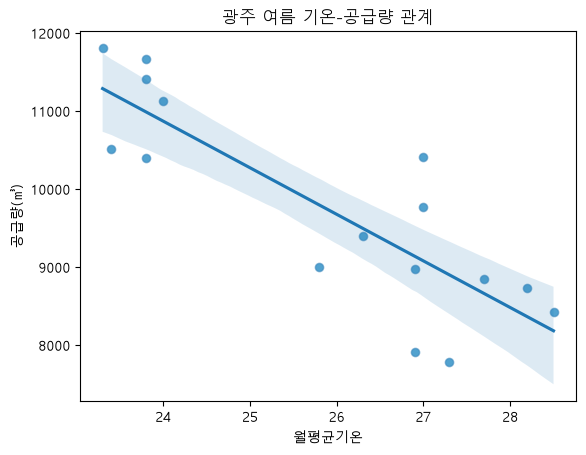

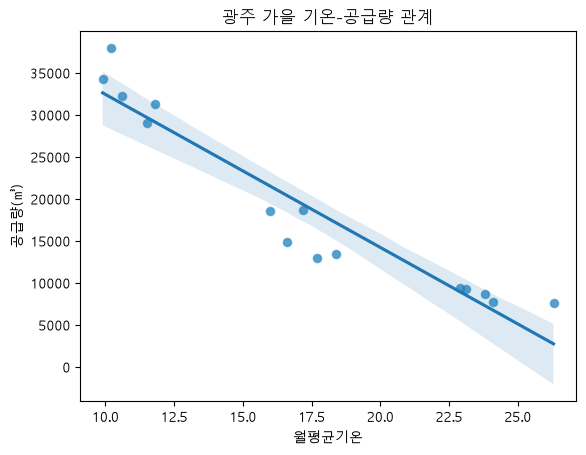

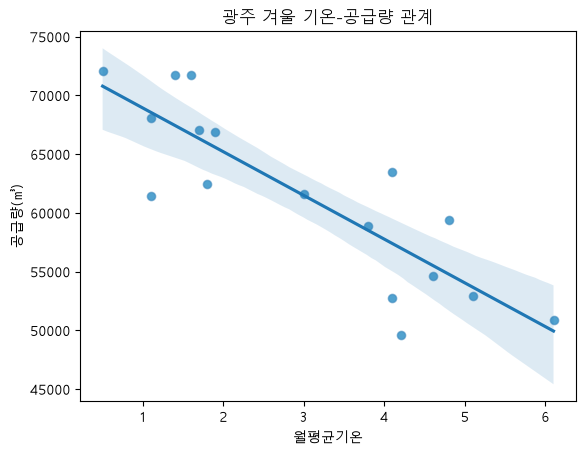

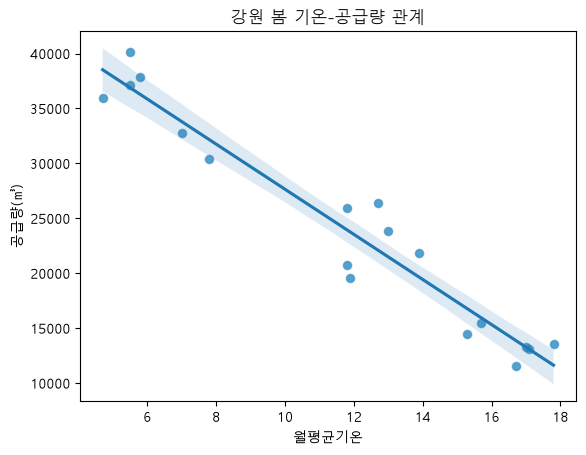

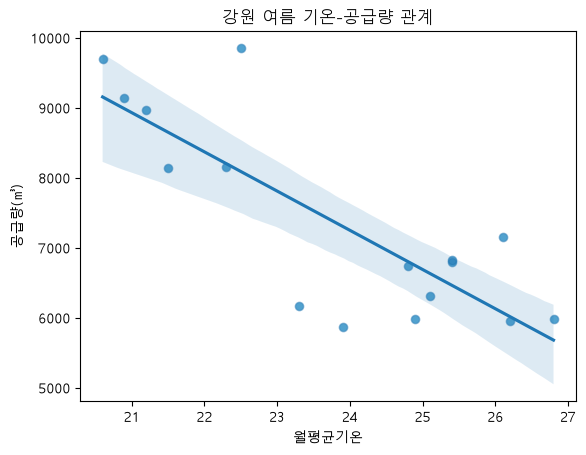

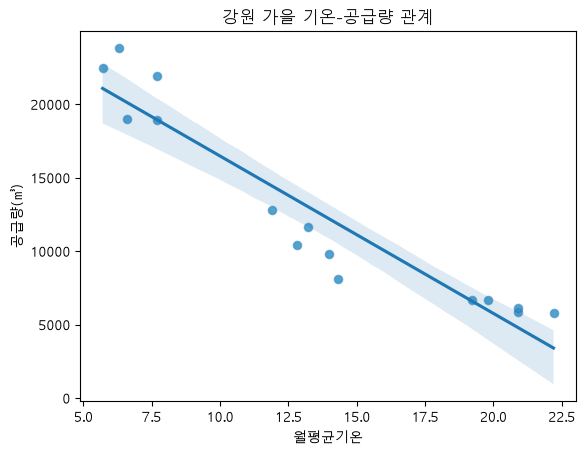

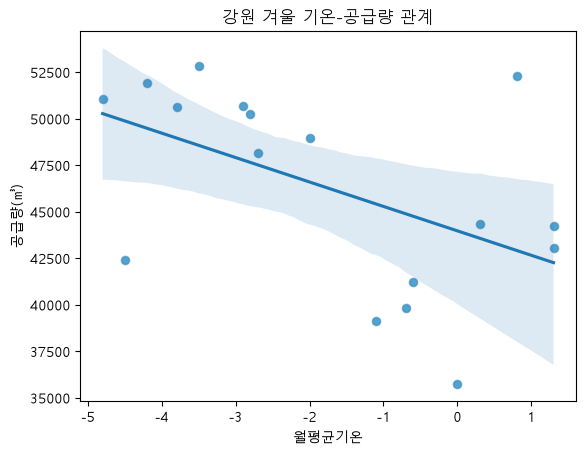

In [17]:
#산점도 : 관계 확인용 / 두 변수의 관계를 보여준다
#기온이 올라갈 수록 공급량이 줄어든다는 것을 확인 -> 음의 상관관계 확인/
for region in regions:
    for season in seasons:
        data = filtered_df[(filtered_df['시도'] == region) & (filtered_df['계절'] == season)]
        if not data.empty:
            sns.scatterplot(x='월평균기온', y='공급량(㎥)', data=data, color='skyblue')
            plt.title(f'{region} {season} 기온-공급량 관계')
            plt.xlabel('월평균기온(℃)')
            plt.ylabel('공급량(㎥)')
            sns.regplot(x='월평균기온', y='공급량(㎥)', data=data, scatter_kws={'alpha':0.5})
            plt.show()

#회귀선에 밀집되어 있는가를 본다 => 기온과 공급량의 관계가 얼마나 강한지를 볼 수 있다 => 강한 상관관계 / 약한상관관계는 다른 요인도 영향을 준다는 신호



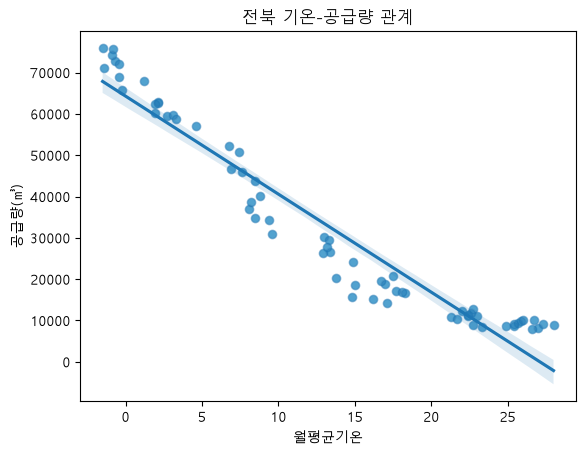

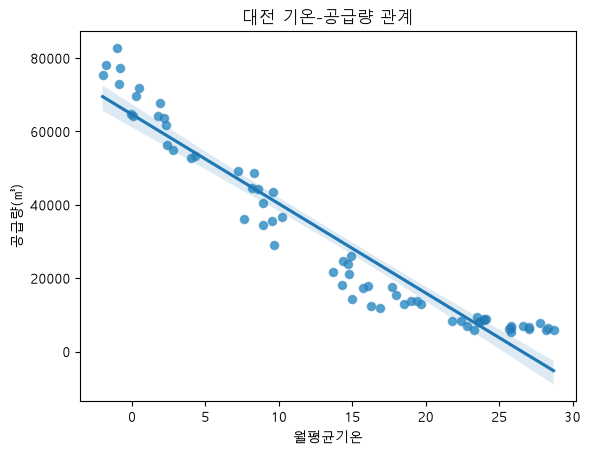

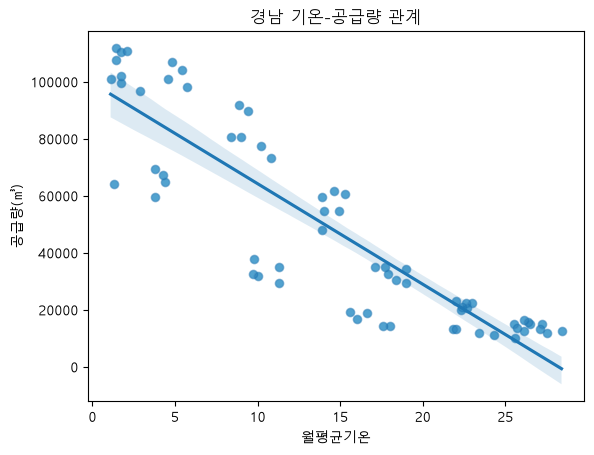

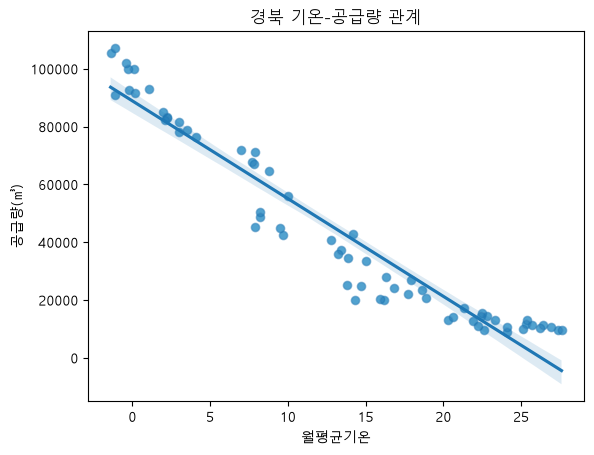

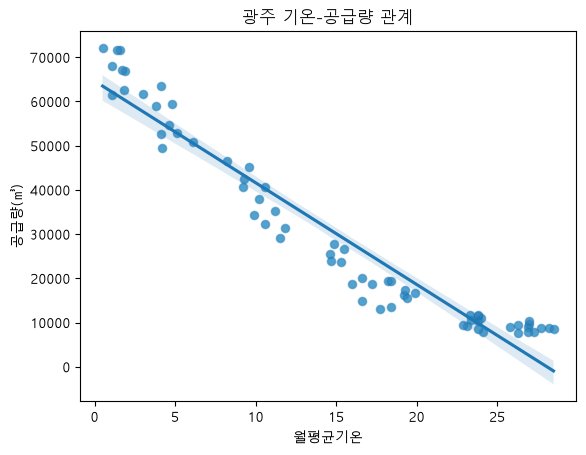

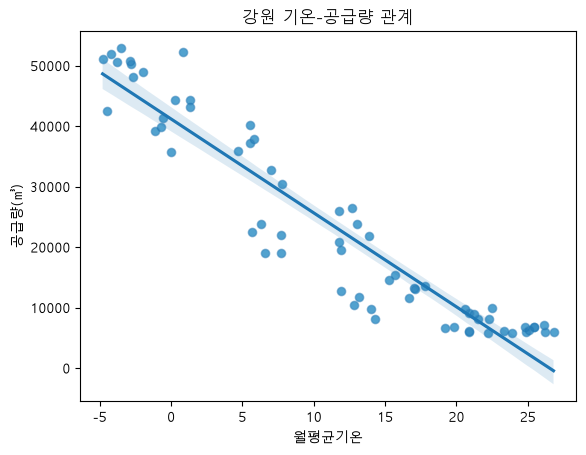

In [18]:

for region in regions:
      data = filtered_df[(filtered_df['시도'] == region)]
      if not data.empty:
          sns.scatterplot(x='월평균기온', y='공급량(㎥)', data=data, color='skyblue')
          plt.title(f'{region} 기온-공급량 관계')
          plt.xlabel('월평균기온(℃)')
          plt.ylabel('공급량(㎥)')
          sns.regplot(x='월평균기온', y='공급량(㎥)', data=data, scatter_kws={'alpha':0.5})
          plt.show()

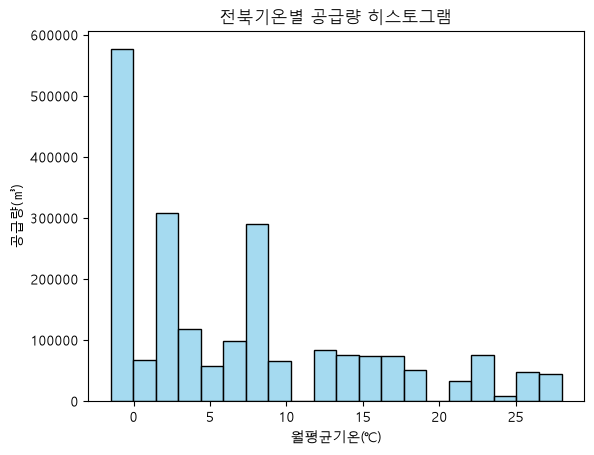

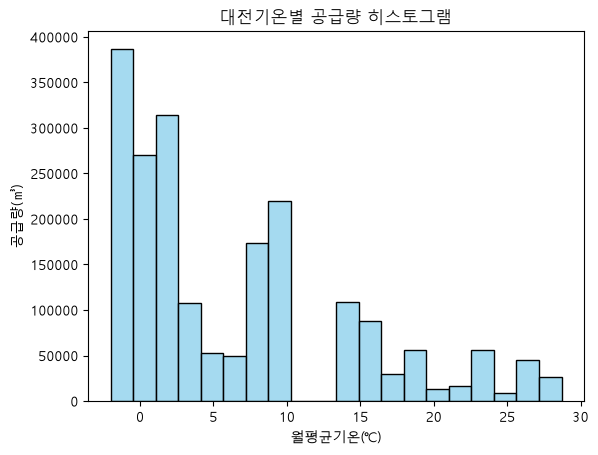

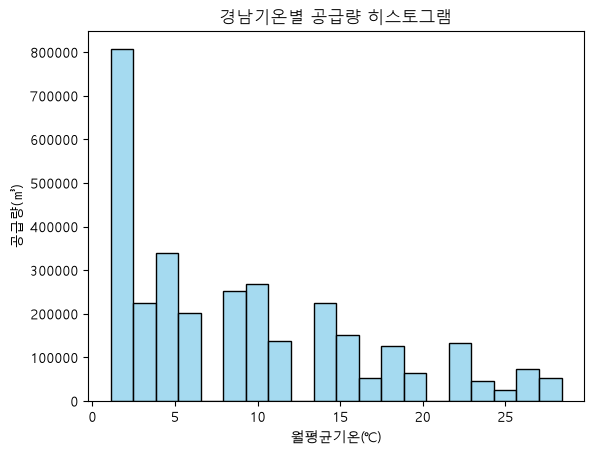

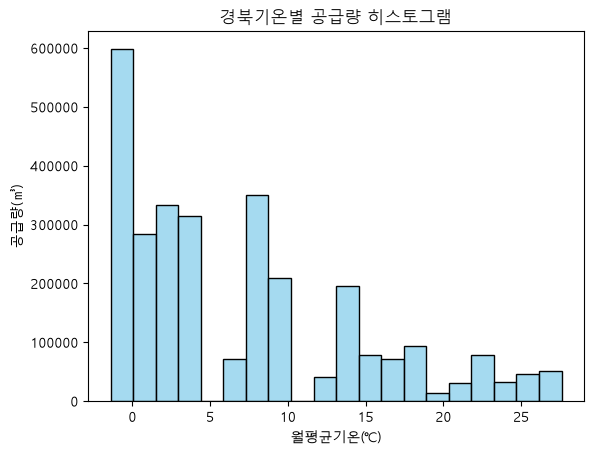

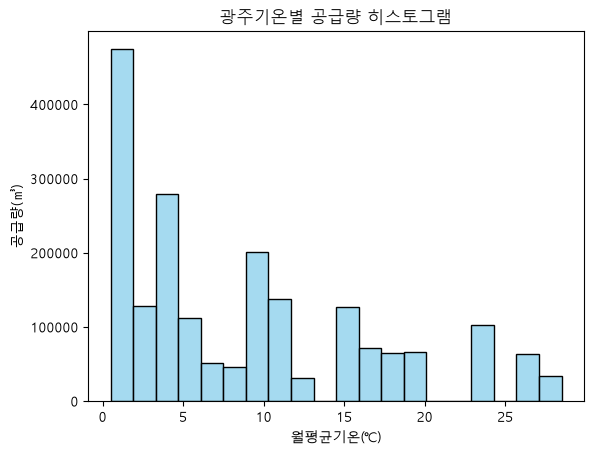

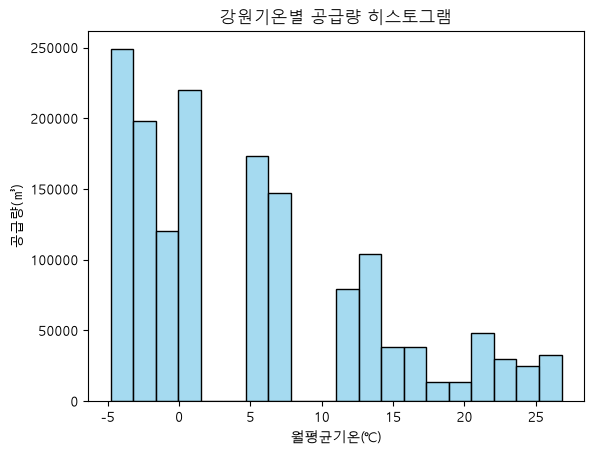

In [19]:
#히스토그램 : 분포 확인용 => 공급량이 어느 구간에 몰려있는지
#전북의 경우 0도 근처에서 민감하게 반응한다는 것을 보여준다.
#강원의 경우 평균기온의 넓이?가 더 넓다/ 강원은 더 낮은 구간이 존재하고 그 구간에서 공급량이 크게 증가한다=공급량변화도 더 크다  => 강원이 5개 지역 대비 겨울철 한파를 직접적으로 겪는 지역이다.

import seaborn as sns
import matplotlib.pyplot as plt

for region in regions:
        data = filtered_df[(filtered_df['시도'] == region)]
        if not data.empty:
            # 기온을 구간으로 나누고 공급량 분포 확인
            sns.histplot(data=data, x='월평균기온', weights=data['공급량(㎥)'], bins=20, color='skyblue')
            plt.title(f'{region}기온별 공급량 히스토그램')
            plt.xlabel('월평균기온(℃)')
            plt.ylabel('공급량(㎥)')
            plt.show()


C:\Users\GRS\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


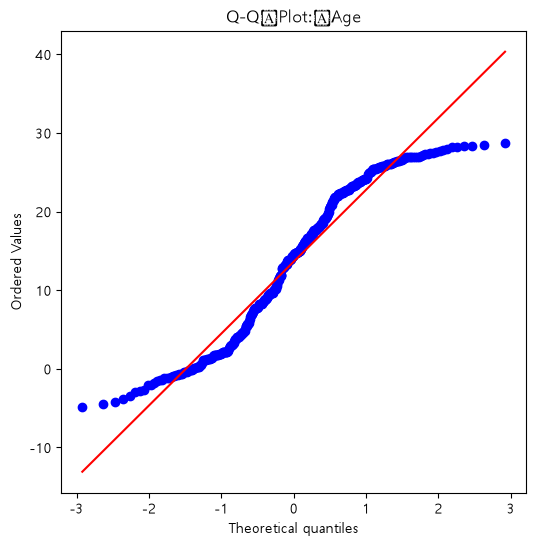

In [20]:
from	scipy	import	stats
fig,	ax	=	plt.subplots(figsize=(6,	6))
stats.probplot(filtered_df['월평균기온'].dropna(),	dist='norm',	plot=ax)
ax.set_title('Q-Q	Plot:	Age')
plt.show()

#s자 곡석 : 꼬리가 정규분포보다 두꺼움

In [21]:
print(f"왜도(Skewness):	{filtered_df['월평균기온'].skew():.3f}")
print(f"첨도(Kurtosis):	{filtered_df['월평균기온'].kurt():.3f}")

#왜도 : 음수, 왼쪽 꼬리가 김
#척도 : 음수, 정규분포보다 완만함

왜도(Skewness):	-0.132
첨도(Kurtosis):	-1.248


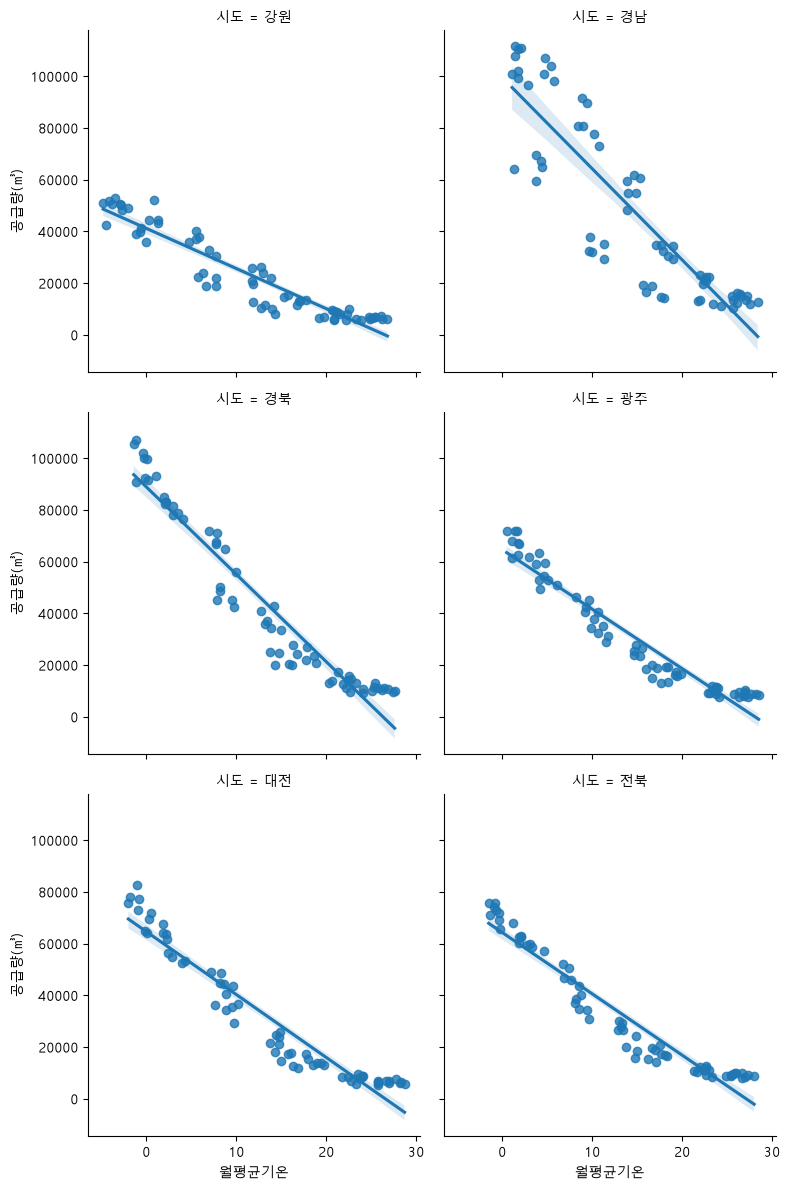

In [ ]:
df_ans	=	sns.load_dataset("anscombe")
sns.lmplot(x='월평균기온',	y='공급량(㎥)',	col='시도',	data=filtered_df,
col_wrap=2,	height=4)
plt.show()

#산점도+선형회귀선+95%신뢰구간 => 점:데이터(기온,공급량) / 직선 : 지역의 회귀선 / 파란띠 : 95%신뢰구간

#경남의 경우 급격한 기울기 -> 공급량의 최대치와 최소치의 차이가 크다 -> 경남의 인구수가 많기 때문에 강원과의 차이가 보인다.

In [ ]:
from scipy.stats import linregress

for region in ['전북', '대전', '경남', '경북', '광주', '강원']:
    data = filtered_df[filtered_df['시도'] == region]
    slope, intercept, r_value, p_value, std_err = linregress(
        data['월평균기온'], data['공급량(㎥)']
    )
    print(f"{region}: 기울기={slope:.0f}, 절편={intercept:.0f}, "
          f"R²={r_value**2:.3f}, p={p_value:.4f}")

#경남의 기울기로 경남의 소비량 자체가 커서 기온에 따른 변화도 크다.   
#절편 : 진짜 민감도 = 기울기/절편
#강원	−3.77%	기온 1도↑에 기저수요 대비 3.77% 감소
#광주	−3.56%	전북	−3.69%	경남	−3.55%	대전	−3.77%	경북	−3.80%
# -3.56 ~ -3.80%으로 비슷한 반응정도 / 지역 규모의 차이 


전북: 기울기=-2372, 절편=64294, R²=0.932, p=0.0000
대전: 기울기=-2434, 절편=64646, R²=0.924, p=0.0000
경남: 기울기=-3527, 절편=99511, R²=0.789, p=0.0000
경북: 기울기=-3381, 절편=88898, R²=0.928, p=0.0000
광주: 기울기=-2301, 절편=64638, R²=0.930, p=0.0000
강원: 기울기=-1553, 절편=41169, R²=0.891, p=0.0000


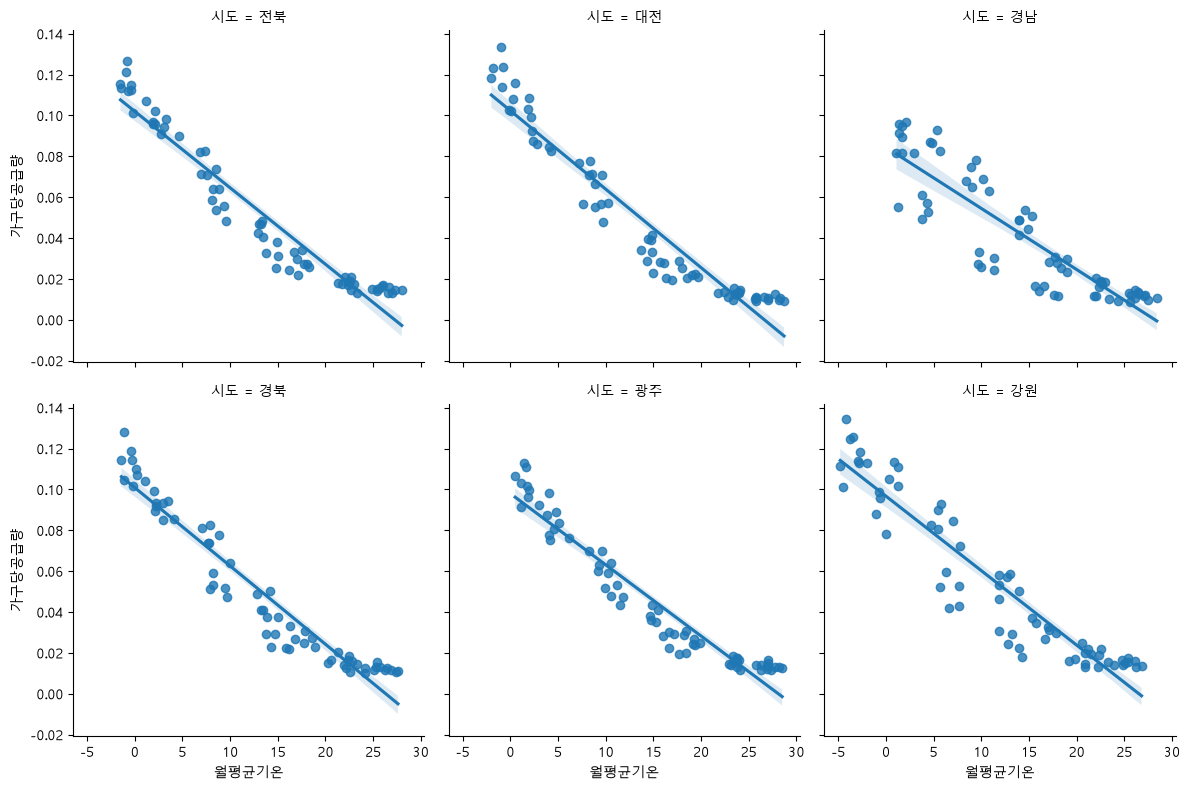

In [ ]:
# 가구당 공급량 컬럼 추가
filtered_df['가구당공급량'] = filtered_df['공급량(㎥)'] / filtered_df['가구수(개)']

# 가구당 공급량으로 lmplot 다시 그리기
sns.lmplot(
    x='월평균기온',
    y='가구당공급량',
    col='시도',
    data=filtered_df,
    col_wrap=3,
    height=4,
    col_order=['전북', '대전', '경남', '경북', '광주', '강원']
)
plt.show()

#경남의 편자는 큰 편 => 지역의 특성(창원, 김해, 양산, 통영 등 대표기온으로 삼아서 측정하기에는 지역적 편차가 존재할 수 있음을 알 수 있다.)

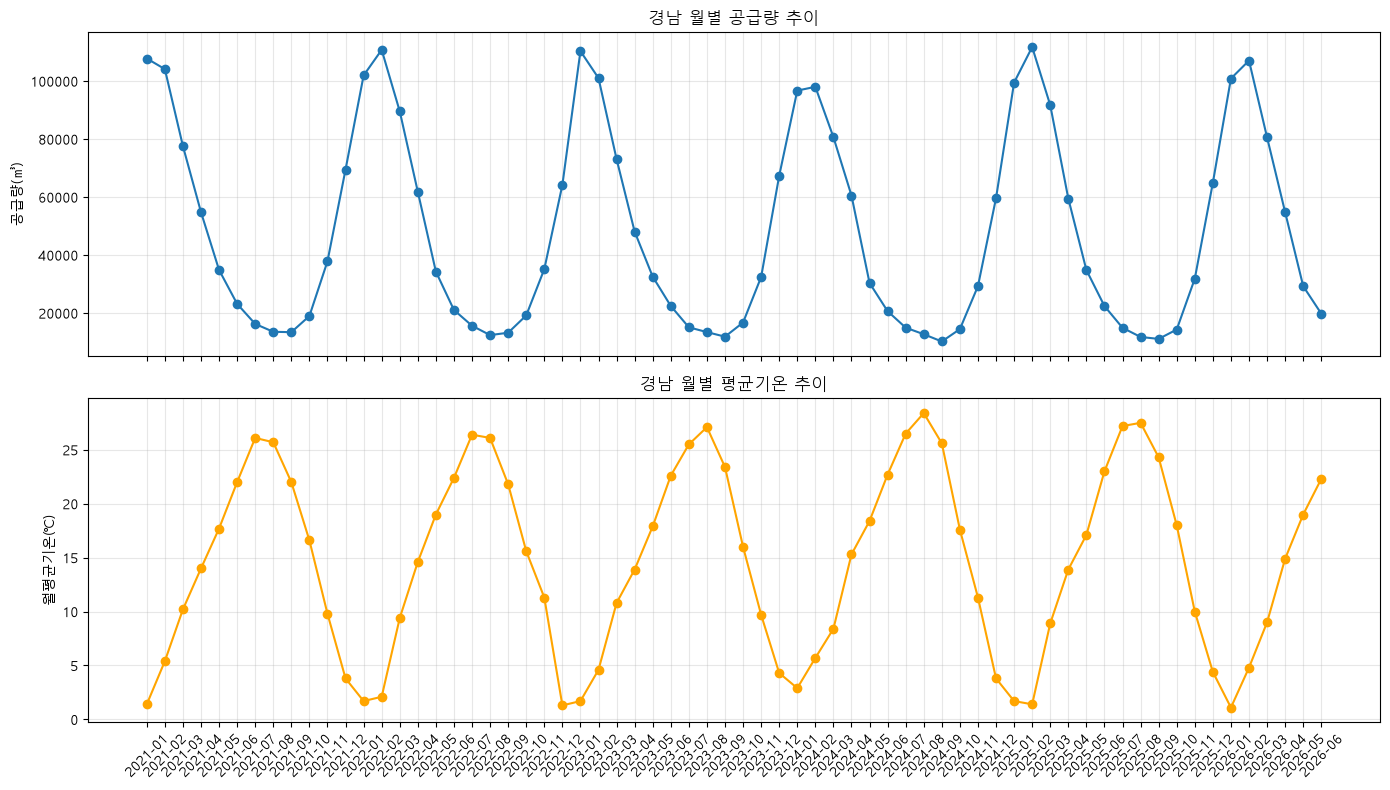

In [27]:
import matplotlib.pyplot as plt

gyeongnam = filtered_df[filtered_df['시도'] == '경남'].sort_values('연월')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 위: 공급량 시계열
axes[0].plot(gyeongnam['연월'], gyeongnam['공급량(㎥)'], marker='o')
axes[0].set_title('경남 월별 공급량 추이')
axes[0].set_ylabel('공급량(㎥)')
axes[0].grid(True, alpha=0.3)

# 아래: 기온 시계열 (비교용)
axes[1].plot(gyeongnam['연월'], gyeongnam['월평균기온'], marker='o', color='orange')
axes[1].set_title('경남 월별 평균기온 추이')
axes[1].set_ylabel('월평균기온(℃)')
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


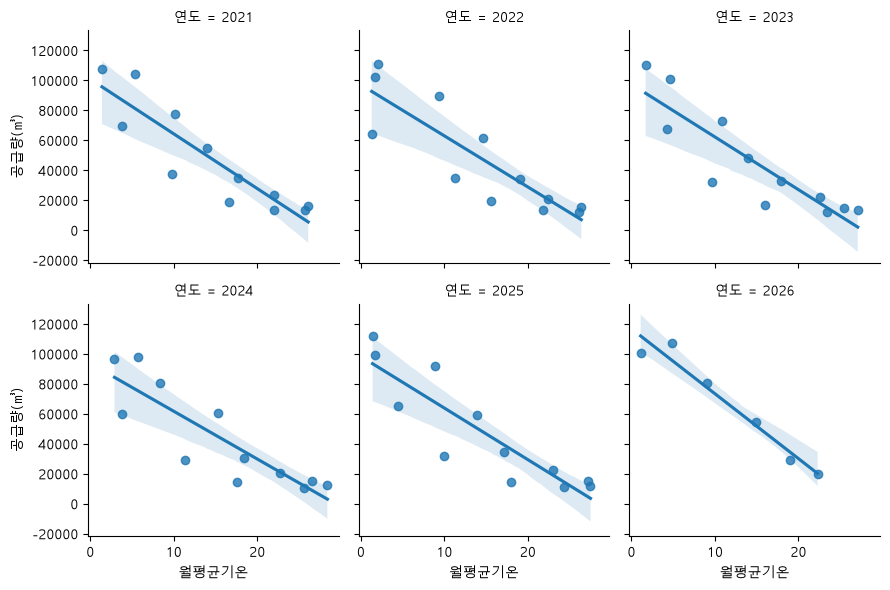

In [ ]:
import pandas as pd

# 경남 데이터 다시 뽑고, '연도' 컬럼 추가
gyeongnam = filtered_df[filtered_df['시도'] == '경남'].copy()
gyeongnam['연도'] = pd.to_datetime(gyeongnam['연월']).dt.year

# lmplot
sns.lmplot(
    data=gyeongnam,
    x='월평균기온',
    y='공급량(㎥)',
    col='연도',
    col_wrap=3,
    height=3
)
plt.show()


#경남의 5년치 데이터에는 큰 이상치가 없다/

In [ ]:
target_months = ['2021-12', '2022-01', '2022-02',   # 22년 겨울
                 '2022-12', '2023-01', '2023-02']    # 23년 겨울

gyeongnam_winter = gyeongnam[gyeongnam['연월'].isin(target_months)]
print(gyeongnam_winter[['연월', '월평균기온', '월평균최저기온', '공급량(㎥)']])

# 23년 겨울은 12월부터 이미 추웠음 (평균 1.3℃) → 12월에 이미 보일러를 강하게 켜기 시작
# 이 습관이 1월에 이어져서 같은 기온이어도 더 많이 사용
# 반면 22년 1월은 12월(3.8℃)에서 갑자기 1.7℃로 떨어진 상황이라, 소비 전환이 늦어져 상대적으로 덜 씀
#"관성 효과"가 실제로 존재한다는 증거
#이 6개월 데이터를 정리하면 두 시즌은 아래 그림 같은 대비를 보여:
#22년 겨울: 온화한 12월 → 갑자기 추운 1월 → 여전히 추운 2월. 공급량은 12월 낮음, 1월 급증, 2월 정점.
#23년 겨울: 처음부터 추운 12월 → 예상대로 추운 1월 → 풀리는 2월. 공급량은 12월 낮음, 1월 정점, 2월 감소.

          연월    월평균기온   월평균최저기온        공급량(㎥)
143  2021-12 3.800000 -1.300000  69504.354340
144  2022-01 1.700000 -3.400000 101960.612700
145  2022-02 2.100000 -3.200000 110786.088800
155  2022-12 1.300000 -3.200000  64188.452130
156  2023-01 1.700000 -3.600000 110347.345400
157  2023-02 4.600000 -0.700000 101036.240800


In [ ]:
#학습 진행을 위해 우선 sklearn 라이브러리 설치 (싸이킷런)
!pip install scikit-learn

In [ ]:
#학습데이터와 검증데이터로 분리(test_size=20%/random_state=42(팀끼리는 random은 통일 7 or 42))
train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42)